### Imports

In [1]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from extraction_1D import run_1d_pipeline
from skimage.feature import hog
from extraction_2D import run_2d_pipeline
import matplotlib
import matplotlib.patches as mpatches

### STEP 1: load CSD image, SVM model and json labels

In [2]:

# 1. setup paths 
# SVM model, go up one level with '../'
MODEL_PATH = "../classifier_training/svm_model.pkl"

# new images and labels are right in this folder
IMG_DIR = "csd_images"
LBL_DIR = "csd_labels"

# first test image 
TEST_IMAGE_NAME = "navtest_001_alpha0.251_wobble19.4.png" 
TEST_JSON_NAME = TEST_IMAGE_NAME.replace(".png", ".json")

# 2. load the Trained SVM Pipeline
with open(MODEL_PATH, "rb") as f:
    pipeline = pickle.load(f)
print("YES: SVM Pipeline loaded successfully.")

# 3. load the Test Image & Convert to Grayscale
# its a must toprocess the image EXACTLY how the SVM was trained
def load_image_gray(path: str) -> np.ndarray:
    img = plt.imread(path)
    if img.ndim == 3:
        # Collapse RGBA to luminance 
        gray = 0.2989 * img[:, :, 0] + 0.5870 * img[:, :, 1] + 0.1140 * img[:, :, 2]
    else:
        gray = img.astype(np.float32)
    return gray.astype(np.float32)

img_path = os.path.join(IMG_DIR, TEST_IMAGE_NAME)
img = load_image_gray(img_path)
print(f"YES: Loaded test image: {TEST_IMAGE_NAME} (Shape: {img.shape})")

# 4. load the Ground Truth (1,1) Coordinates from JSON
json_path = os.path.join(LBL_DIR, TEST_JSON_NAME)

with open(json_path, "r") as f:
    data = json.load(f)
    
true_target = data.get("target_pixel")
if true_target:
    true_x = true_target["col_px"]
    true_y = true_target["row_px"]
    print(f"YES: Ground Truth (1,1) Target is at: X={true_x}, Y={true_y}")
else:
    print("NO: Warning: No (1,1) target found in this JSON.")

YES: SVM Pipeline loaded successfully.
YES: Loaded test image: navtest_001_alpha0.251_wobble19.4.png (Shape: (500, 500))
YES: Ground Truth (1,1) Target is at: X=299, Y=199


### STEP 2: Run 1D extraction on the CSD and extract the matrix 

In [3]:
# pass 'img' (from Cell 1) into the function
M, m1, m2, v1, v2, lines = run_1d_pipeline(img, show_plots=False)

print(f"\n Navigation Vectors Acquired.")
print(f"   v1 (Diagonal Step): [{v1[0]:.4f}, {v1[1]:.4f}]")
print(f"   v2 (Steep Step):    [{v2[0]:.4f}, {v2[1]:.4f}]")



Detected row peaks: 5
Detected col peaks: 5
Total detected points from multi-slice: 550
Inliers: 87 / 550
Slope: 0.2718
~~~~~~~~~~ PASS 1: Diagonal Lines ~~~~~~~~~~~~~
Found diagonal line with 92 points (slope: 0.27)
Found diagonal line with 91 points (slope: 0.28)
Found diagonal line with 79 points (slope: 0.26)

~~~~~~~~~~ PASS 2: Steep Lines ~~~~~~~~~~~~~
Found steep line with 69 points (slope: 3.61)
Found steep line with 68 points (slope: 3.67)

Total lines found: 5
Saved iterative RANSAC result
Diagonal lines: 3
Steep lines: 2
Displayed two slope families visualization with custom legend

Final extracted lines:
diagonal | slope = 0.2735 | points = 92
diagonal | slope = 0.2778 | points = 91
diagonal | slope = 0.2646 | points = 79
steep    | slope = 3.6094 | points = 69
steep    | slope = 3.6731 | points = 68

Filtered lines:
diagonal | slope = 0.2735 | points = 92
diagonal | slope = 0.2778 | points = 91
diagonal | slope = 0.2646 | points = 79
steep    | slope = 3.6094 | points = 69

### STEP 5: 2D extraction 

<Figure size 640x480 with 0 Axes>

2D Preprocessing complete.
found 32 raw line segments using hough transform


<Figure size 640x480 with 0 Axes>

saved hough lines visualization
raw diagonal segments: 16
raw steep segments: 16
clean diagonal segments: 9
clean steep segments: 16


<Figure size 640x480 with 0 Axes>

saved clean hough families plot

final 2d results:
diagonal slope: 0.2413 (from 1 physical lines)
steep slope: 3.5390 (from 2 physical lines)
slope ratio (alpha product proxy): 14.67


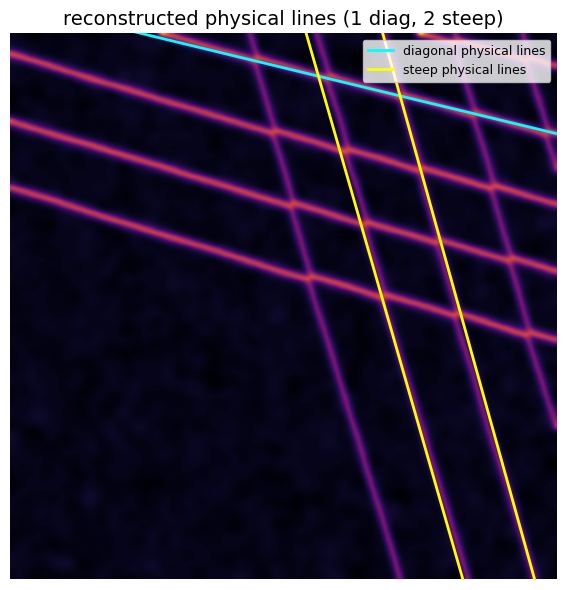

saved reconstructed physical lines plot


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

saved color-mapped physical lines plot
saved proof

2d pipeline complete. saved everything to your folders.
Slope Cross Validation
Method         Diagonal slope    Steep slope
1D RANSAC              0.2720         3.6412
2D Hough               0.2413         3.5390
Difference             0.0307         0.1022

 Methods agree


In [4]:
M_2d, diag_2d, steep_2d, matrix_data_2d, final_lines_2d = run_2d_pipeline(img)

print("Slope Cross Validation")
print(f"{'Method':<12} {'Diagonal slope':>16} {'Steep slope':>14}")
print(f"{'1D RANSAC':<12} {m1:>16.4f} {m2:>14.4f}")
print(f"{'2D Hough':<12} {diag_2d:>16.4f} {steep_2d:>14.4f}")
print(f"{'Difference':<12} {abs(m1-diag_2d):>16.4f} {abs(m2-steep_2d):>14.4f}")

agreement = abs(m1 - diag_2d) < 0.05 and abs(m2 - steep_2d) < 0.5
print(f"\n{' Methods agree' if agreement else ' Methods disagree'}")

### STEP 3: Geometric jump and SVM verification

The CSD is slanted. If navigator wants to move from empty state to (1,1), it can't just move diagonally bc of cross-capacitance. So, this step creates some points over the image where the navigator can ofc "navigate" to. 

In [5]:
def extract_hog(patch):
    return hog(patch, orientations=9, pixels_per_cell=(8,8),
               cells_per_block=(2,2), visualize=False)

half = 42
h, w = img.shape

# find intersections of diagonal and steep lines
diag_lines  = [l for l in lines if l["type"] == "diagonal"]
steep_lines = [l for l in lines if l["type"] == "steep"]

intersections = []
for d in diag_lines:
    for s in steep_lines:
        md, bd = d["slope"], d["intercept"]
        ms, bs = s["slope"], s["intercept"]
        denom = md - ms
        if abs(denom) < 1e-6:
            continue
        x = (bs - bd) / denom
        y = md * x + bd
        if 0 <= x <= w and 0 <= y <= h:
            intersections.append((x, y))

# sort by distance from bottom-left — closest = lowest charge state region
intersections.sort(key=lambda p: np.sqrt(p[0]**2 + (p[1] - h)**2))

# center of 4 closest intersections = (1,1) center
bottom_4 = intersections[:4]
pred_x   = np.mean([p[0] for p in bottom_4])
pred_y   = np.mean([p[1] for p in bottom_4])
print(f"Found {len(intersections)} intersections")
print(f"Predicted (1,1) center : ({pred_x:.1f}, {pred_y:.1f})")

# SVM Verification at predicted location
px, py   = int(pred_x), int(pred_y)
patch    = img[py-half:py+half+1, px-half:px+half+1]
features = extract_hog(patch).reshape(1, -1)
feat_sc  = pipeline[:-1].transform(features)
score    = pipeline.named_steps["svm"].decision_function(feat_sc)[0]

THRESHOLD = 0
if score > THRESHOLD:
    print(f" (1,1) CONFIRMED at ({px}, {py})   SVM score={score:.4f}")
else:
    print(f"  Verification weak  at ({px}, {py})  SVM score={score:.4f}")

confirmed_x, confirmed_y = px, py
dist = np.sqrt((pred_x - true_x)**2 + (pred_y - true_y)**2)
print(f"Ground truth : ({true_x}, {true_y})")
print(f"Distance     : {dist:.1f} px")

Found 6 intersections
Predicted (1,1) center : (300.0, 198.8)
 (1,1) CONFIRMED at (299, 198)   SVM score=0.7039
Ground truth : (299, 199)
Distance     : 1.0 px


### Calculating lattice period (step size) - not using

In [6]:
# Calculate step size from 1D lines (more reliable than 2D for wobbly images)
# Distance between two parallel diagonal lines = |b2 - b1| / sqrt(1 + m^2)

diag_lines_1d = [l for l in lines if l["type"] == "diagonal"]

if len(diag_lines_1d) >= 2:
    # sort by intercept so we pick adjacent lines
    diag_lines_1d_sorted = sorted(diag_lines_1d, key=lambda l: l["intercept"])
    
    # calculate spacing between each adjacent pair, take the minimum
    spacings = []
    for k in range(len(diag_lines_1d_sorted) - 1):
        b1 = diag_lines_1d_sorted[k]["intercept"]
        b2 = diag_lines_1d_sorted[k+1]["intercept"]
        m  = diag_lines_1d_sorted[k]["slope"]
        d  = abs(b2 - b1) / np.sqrt(1 + m**2)
        spacings.append(d)
    
    step_size = int(min(spacings))
    print(f"1D-derived step size : {step_size} px")
else:
    step_size = 75
    print(f" Fallback step size  : {step_size} px")

# 2D method as cross-check (informational only)
diag_lines_2d = [l for l in final_lines_2d if l["type"] == "diagonal"]
if len(diag_lines_2d) >= 2:
    b1_2d = diag_lines_2d[0]["intercept"]
    b2_2d = diag_lines_2d[1]["intercept"]
    m_2d  = diag_lines_2d[0]["slope"]
    step_2d = int(abs(b2_2d - b1_2d) / np.sqrt(1 + m_2d**2))
    print(f"   2D cross-check      : {step_2d} px  (may span multiple cells)")

1D-derived step size : 57 px


### STEP 4: State machine map

Step size: 75 px


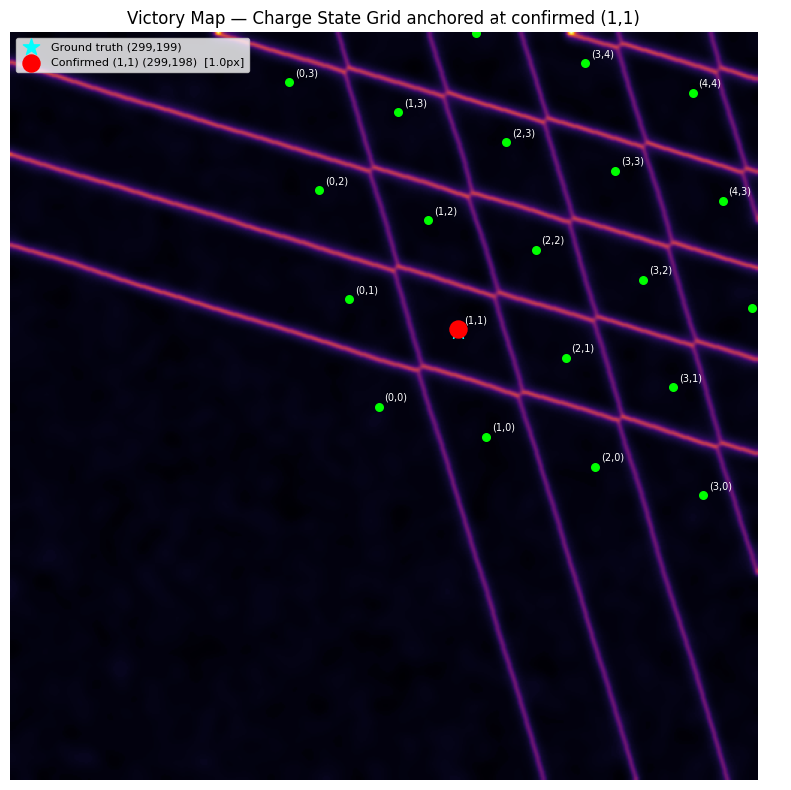

In [7]:
step_size = 75
print(f"Step size: {step_size} px")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img, cmap="inferno")

for i in range(-1, 5):
    for j in range(-1, 5):
        point = np.array([confirmed_x, confirmed_y]) + (i * step_size * v1) - (j * step_size * v2)
        x, y  = int(point[0]), int(point[1])
        if 0 <= x < w and 0 <= y < h:
            is_target = (i == 0 and j == 0)
            ax.scatter(x, y,
                       color="red" if is_target else "lime",
                       s=120 if is_target else 30, zorder=3)
            ax.text(x+4, y-4, f"({i+1},{j+1})", color="white", fontsize=7, zorder=4)

ax.scatter(true_x, true_y, color="cyan", s=150, marker="*", zorder=5,
           label=f"Ground truth ({true_x},{true_y})")
ax.scatter(confirmed_x, confirmed_y, color="red", s=150, zorder=5,
           label=f"Confirmed (1,1) ({confirmed_x},{confirmed_y})  [{dist:.1f}px]")

ax.legend(fontsize=8)
ax.set_title("Victory Map — Charge State Grid anchored at confirmed (1,1)")
ax.axis("off")
plt.tight_layout()
plt.show()

### STEP 5: Tsting 10 images. 

In [8]:
# all 10 test images 
def extract_hog(patch):
    return hog(patch, orientations=9, pixels_per_cell=(8,8),
               cells_per_block=(2,2), visualize=False)

half = 42
test_images = sorted([f for f in os.listdir(IMG_DIR) if f.endswith(".png")])
distances   = []
results_log = []

print(f"Batch evaluation — {len(test_images)} images\n{'─'*65}")

for img_name in test_images:
    # load image and ground truth
    test_img  = load_image_gray(os.path.join(IMG_DIR, img_name))
    json_name = img_name.replace(".png", ".json")
    with open(os.path.join(LBL_DIR, json_name)) as f:
        td = json.load(f)
    gt = td.get("target_pixel")
    if gt is None:
        print(f"  SKIP (no ground truth): {img_name}")
        continue
    gt_x, gt_y = gt["col_px"], gt["row_px"]

    # 1D extraction — no plots
    _, _, _, _, _, lines_t = run_1d_pipeline(test_img, show_plots=False)
    h_t, w_t = test_img.shape

    # geometry: find intersections
    diag_t  = [l for l in lines_t if l["type"] == "diagonal"]
    steep_t = [l for l in lines_t if l["type"] == "steep"]
    ints_t  = []
    for d in diag_t:
        for s in steep_t:
            denom = d["slope"] - s["slope"]
            if abs(denom) < 1e-6:
                continue
            x = (s["intercept"] - d["intercept"]) / denom
            y = d["slope"] * x + d["intercept"]
            if 0 <= x <= w_t and 0 <= y <= h_t:
                ints_t.append((x, y))

    if len(ints_t) < 4:
        print(f"  SKIP (fewer than 4 intersections): {img_name}")
        continue

    ints_t.sort(key=lambda p: np.sqrt(p[0]**2 + (p[1] - h_t)**2))
    pred_x = np.mean([p[0] for p in ints_t[:4]])
    pred_y = np.mean([p[1] for p in ints_t[:4]])
    px_t, py_t = int(pred_x), int(pred_y)

    # SVM verification
    patch    = test_img[py_t-half:py_t+half+1, px_t-half:px_t+half+1]
    features = extract_hog(patch).reshape(1, -1)
    feat_sc  = pipeline[:-1].transform(features)
    score    = pipeline.named_steps["svm"].decision_function(feat_sc)[0]
    confirmed = score > 0

    dist = np.sqrt((pred_x - gt_x)**2 + (pred_y - gt_y)**2)
    distances.append(dist)
    results_log.append((img_name, px_t, py_t, gt_x, gt_y, dist, score, confirmed))

    status = "YYES" if confirmed else "NO "
    print(f"  {status} {img_name[:38]}  "
          f"pred=({px_t},{py_t})  gt=({gt_x},{gt_y})  "
          f"dist={dist:.1f}px  svm={score:.3f}")

print(f"\n{'─'*65}")
print(f"Images evaluated  : {len(distances)}")
print(f"Mean distance     : {np.mean(distances):.1f} px")
print(f"Std               : {np.std(distances):.1f} px")
print(f"Min / Max         : {np.min(distances):.1f} / {np.max(distances):.1f} px")
confirmed_count = sum(1 for r in results_log if r[6] > 0)
print(f"SVM confirmed     : {confirmed_count}/{len(distances)}")

Batch evaluation — 10 images
─────────────────────────────────────────────────────────────────
Detected row peaks: 5
Detected col peaks: 5
Total detected points from multi-slice: 550
Inliers: 87 / 550
Slope: 0.2718
~~~~~~~~~~ PASS 1: Diagonal Lines ~~~~~~~~~~~~~
Found diagonal line with 92 points (slope: 0.27)
Found diagonal line with 91 points (slope: 0.28)
Found diagonal line with 79 points (slope: 0.26)

~~~~~~~~~~ PASS 2: Steep Lines ~~~~~~~~~~~~~
Found steep line with 69 points (slope: 3.61)
Found steep line with 68 points (slope: 3.67)

Total lines found: 5
Saved iterative RANSAC result
Diagonal lines: 3
Steep lines: 2
Displayed two slope families visualization with custom legend

Final extracted lines:
diagonal | slope = 0.2735 | points = 92
diagonal | slope = 0.2778 | points = 91
diagonal | slope = 0.2646 | points = 79
steep    | slope = 3.6094 | points = 69
steep    | slope = 3.6731 | points = 68

Filtered lines:
diagonal | slope = 0.2735 | points = 92
diagonal | slope = 0.277

### CLEAN RESLTS 

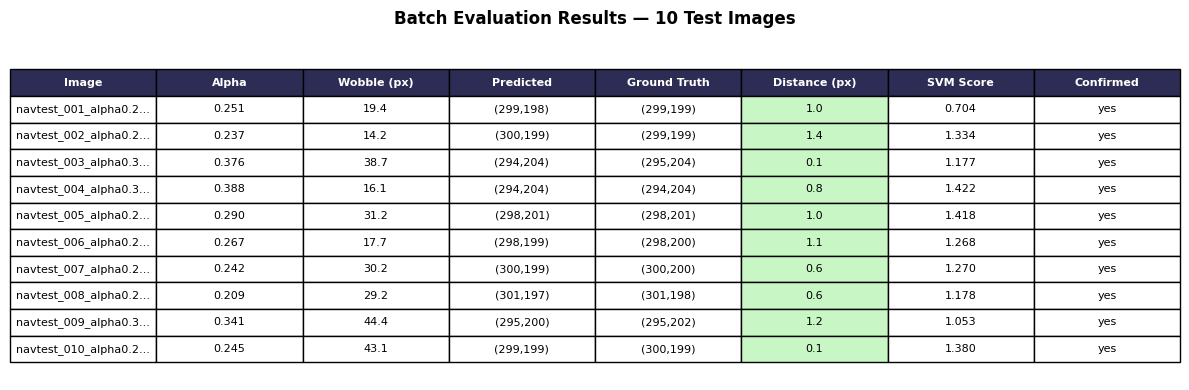

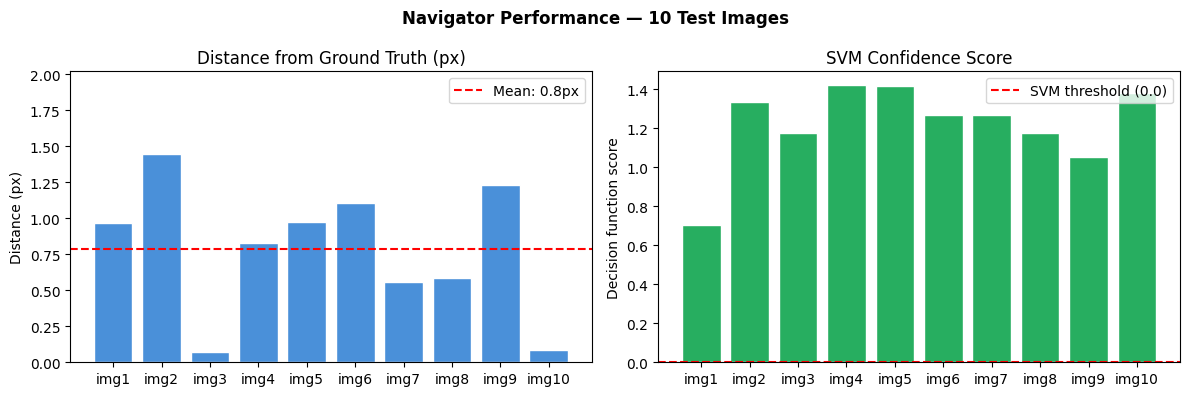

In [9]:
# summary table 
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

col_labels = ["Image", "Alpha", "Wobble (px)", "Predicted", "Ground Truth", "Distance (px)", "SVM Score", "Confirmed"]
table_data = []
for r in results_log:
    img_name, px_t, py_t, gt_x, gt_y, dist, score, confirmed = r
    # extract alpha and wobble from filename
    parts = img_name.replace(".png","").split("_")
    alpha  = next((p.replace("alpha","") for p in parts if "alpha" in p), "?")
    wobble = next((p.replace("wobble","") for p in parts if "wobble" in p), "?")
    table_data.append([
        img_name[:20] + "...",
        alpha,
        wobble,
        f"({px_t},{py_t})",
        f"({gt_x},{gt_y})",
        f"{dist:.1f}",
        f"{score:.3f}",
        "yes" if score > 0 else "no"
    ])

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

# colour header row
for j in range(len(col_labels)):
    table[(0, j)].set_facecolor("#2c2c54")
    table[(0, j)].set_text_props(color="white", fontweight="bold")

# colour distance column — green if <5px, yellow otherwise
for i in range(1, len(table_data)+1):
    dist_val = float(table_data[i-1][5])
    color = "#c8f7c5" if dist_val < 5 else "#f7f0c5"
    table[(i, 5)].set_facecolor(color)

plt.title("Batch Evaluation Results — 10 Test Images", fontweight="bold", fontsize=12, pad=20)
plt.tight_layout()
plt.show()

# bar chart of distances 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

img_labels = [f"img{i+1}" for i in range(len(results_log))]
dists      = [r[5] for r in results_log]
scores     = [r[6] for r in results_log]

axes[0].bar(img_labels, dists, color="#4a90d9", edgecolor="white")
axes[0].axhline(np.mean(dists), color="red", linestyle="--", label=f"Mean: {np.mean(dists):.1f}px")
axes[0].set_title("Distance from Ground Truth (px)")
axes[0].set_ylabel("Distance (px)")
axes[0].set_ylim(0, max(dists) * 1.4)
axes[0].legend()

axes[1].bar(img_labels, scores, color="#27ae60", edgecolor="white")
axes[1].axhline(0, color="red", linestyle="--", label="SVM threshold (0.0)")
axes[1].set_title("SVM Confidence Score")
axes[1].set_ylabel("Decision function score")
axes[1].legend()

plt.suptitle("Navigator Performance — 10 Test Images", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()